<a href="https://colab.research.google.com/github/EverHernandez01/Teoria_de_se-ales/blob/main/Taller/Ejercicio_espectro_dB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

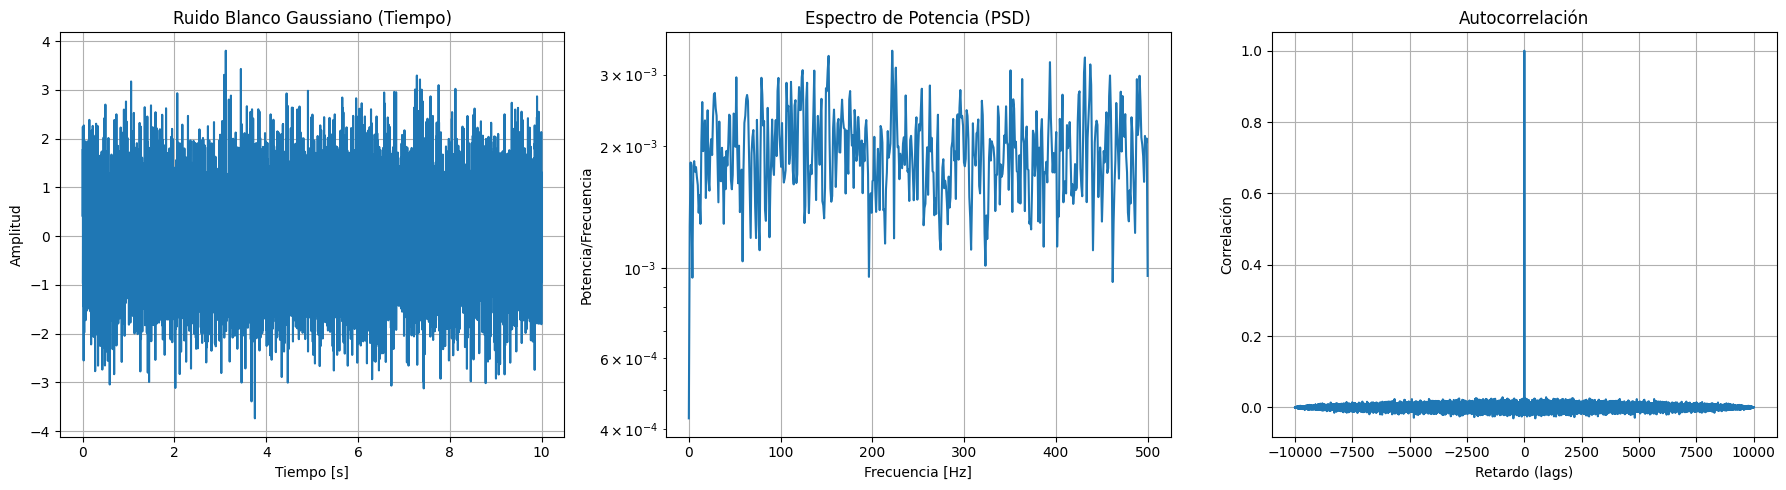

0.9752679753477971


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 1000  # Frecuencia de muestreo (Hz)
N = 10000  # Número de muestras
t = np.arange(N) / fs  # Vector de tiempo

# Generar ruido blanco gaussiano
np.random.seed(0)
ruido = np.random.normal(0, 1, N)

# -----------------------------
# PSD (Welch)
# -----------------------------
f, Pxx = welch(ruido, fs, nperseg=1024)

# -----------------------------
# Autocorrelación
# -----------------------------
autocorr = np.correlate(ruido, ruido, mode='full')
lags = np.arange(-N+1, N)

# Normalización
autocorr = autocorr / np.max(autocorr)

# -----------------------------
# GRÁFICAS (1 fila, 3 columnas)
# -----------------------------
plt.figure(figsize=(18, 5))

# 1. Señal en el tiempo
plt.subplot(1, 3, 1)
plt.plot(t, ruido)
plt.title("Ruido Blanco Gaussiano (Tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

# 2. PSD
plt.subplot(1, 3, 2)
plt.semilogy(f, Pxx)
plt.title("Espectro de Potencia (PSD)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia/Frecuencia")
plt.grid()

# 3. Autocorrelación
plt.subplot(1, 3, 3)
plt.plot(lags, autocorr)
plt.title("Autocorrelación")
plt.xlabel("Retardo (lags)")
plt.ylabel("Correlación")
plt.grid()

plt.tight_layout()
plt.show()

print(np.var(ruido))

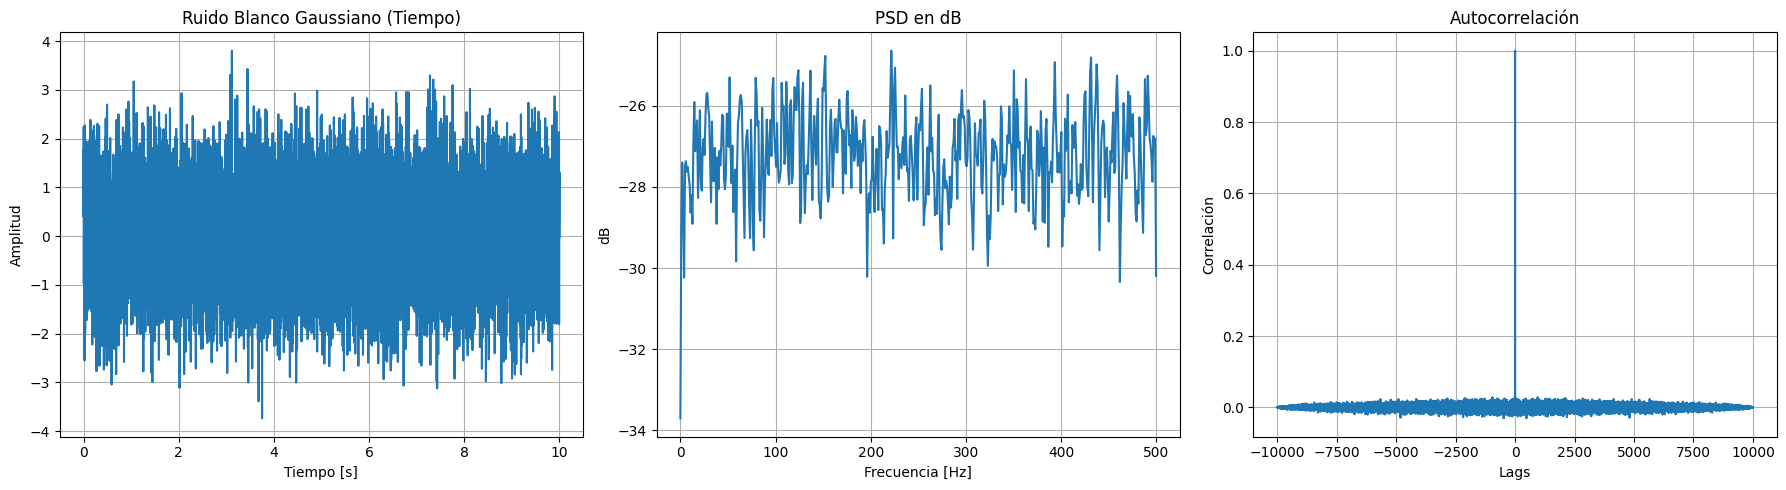

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Parámetros
fs = 1000  # Frecuencia de muestreo (Hz)
N = 10000  # Número de muestras
t = np.arange(N) / fs  # Vector de tiempo

# Ruido blanco gaussiano
np.random.seed(0)
ruido = np.random.normal(0, 1, N)

# -----------------------------
# PSD (Welch)
# -----------------------------
f, psd = welch(ruido, fs, nperseg=1024)

# PSD en dB
psd_db = 10 * np.log10(psd + 1e-10)

# -----------------------------
# Autocorrelación
# -----------------------------
autocorr = np.correlate(ruido, ruido, mode='full')
lags = np.arange(-N+1, N)
autocorr = autocorr / np.max(autocorr)

# -----------------------------
# GRÁFICAS (1 fila, 3 columnas)
# -----------------------------
plt.figure(figsize=(18, 5))

# 1. Señal en el tiempo
plt.subplot(1, 3, 1)
plt.plot(t, ruido)
plt.title("Ruido Blanco Gaussiano (Tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

# 2. PSD en dB
plt.subplot(1, 3, 2)
plt.plot(f, psd_db)
plt.title("PSD en dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
plt.grid()

# 3. Autocorrelación
plt.subplot(1, 3, 3)
plt.plot(lags, autocorr)
plt.title("Autocorrelación")
plt.xlabel("Lags")
plt.ylabel("Correlación")
plt.grid()

plt.tight_layout()
plt.show()

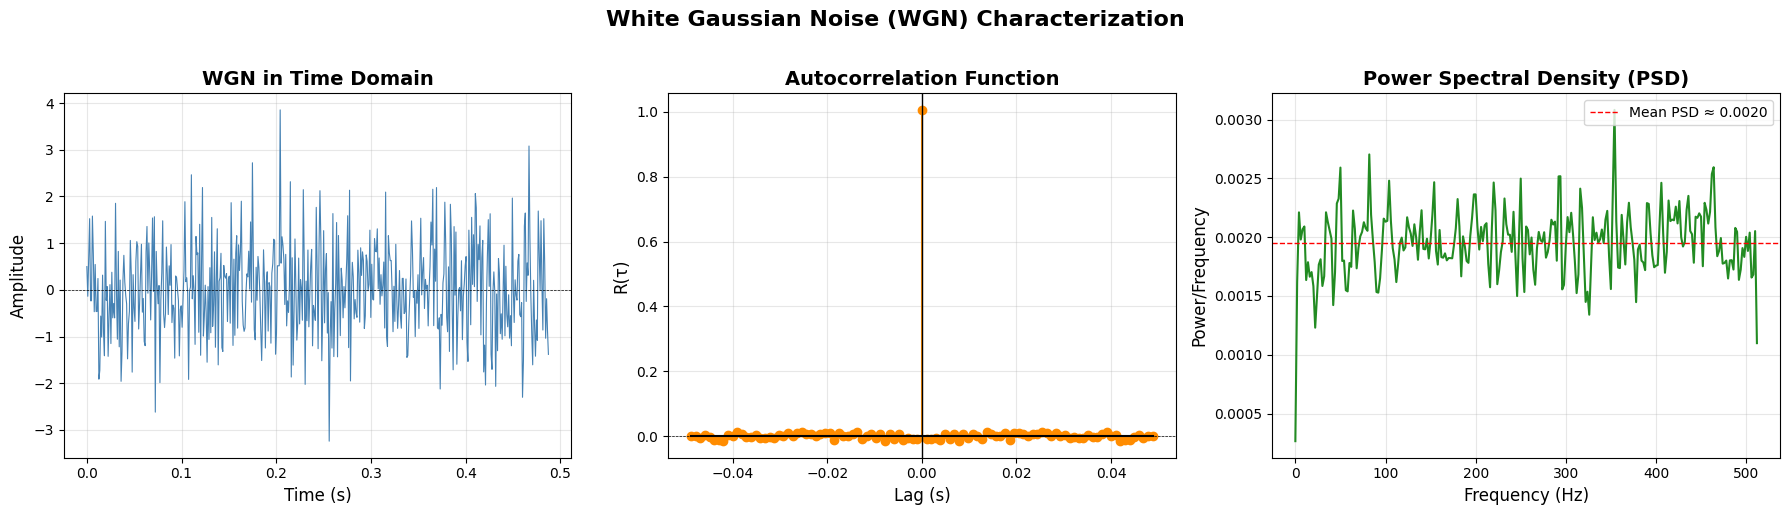

WHITE GAUSSIAN NOISE STATISTICS
Number of samples:      16384
Sampling frequency:     1024 Hz
Standard deviation:     1
Mean of WGN:            0.001467
Variance of WGN:        1.006164
Autocorr at lag 0:      1.006167
Mean PSD value:         0.001954


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.signal import welch

# ============================================================
# Parameters
# ============================================================
np.random.seed(42)          # For reproducibility
N = 16384                   # Number of samples
fs = 1024                   # Sampling frequency (Hz)
sigma = 1                   # Standard deviation of WGN

# ============================================================
# Generate White Gaussian Noise
# ============================================================
wgn = np.random.normal(loc=0, scale=sigma, size=N)
t = np.arange(N) / fs       # Time vector (seconds)

# ============================================================
# Compute Autocorrelation Function
# ============================================================
autocorr = correlate(wgn, wgn, mode='full') / N
lags = np.arange(-N+1, N) / fs

mid = len(autocorr) // 2
lag_range = 50
autocorr_plot = autocorr[mid-lag_range:mid+lag_range+1]
lags_plot = lags[mid-lag_range:mid+lag_range+1]

# ============================================================
# Compute Power Spectral Density (PSD)
# ============================================================
freqs, psd = welch(wgn, fs=fs, nperseg=512)

# ============================================================
# Plotting - All Three in One Row
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Time Domain Signal ---
axes[0].plot(t[:500], wgn[:500], linewidth=0.8, color='steelblue')
axes[0].set_title('WGN in Time Domain', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Amplitude', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# --- Plot 2: Autocorrelation Function ---
# FIXED: Removed 'use_line_collection' parameter
axes[1].stem(lags_plot, autocorr_plot, linefmt='darkorange',
             markerfmt='o', basefmt='k-')
axes[1].set_title('Autocorrelation Function', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (s)', fontsize=12)
axes[1].set_ylabel('R(τ)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=1)

# --- Plot 3: Power Spectral Density ---
axes[2].plot(freqs, psd, linewidth=1.5, color='forestgreen')
axes[2].set_title('Power Spectral Density (PSD)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)', fontsize=12)
axes[2].set_ylabel('Power/Frequency', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=np.mean(psd), color='red', linestyle='--',
                linewidth=1, label=f'Mean PSD ≈ {np.mean(psd):.4f}')
axes[2].legend(loc='upper right', fontsize=10)

# ============================================================
# Final Formatting
# ============================================================
plt.suptitle('White Gaussian Noise (WGN) Characterization',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Print Key Statistics
# ============================================================
print("=" * 60)
print("WHITE GAUSSIAN NOISE STATISTICS")
print("=" * 60)
print(f"Number of samples:      {N}")
print(f"Sampling frequency:     {fs} Hz")
print(f"Standard deviation:     {sigma}")
print(f"Mean of WGN:            {np.mean(wgn):.6f}")
print(f"Variance of WGN:        {np.var(wgn):.6f}")
print(f"Autocorr at lag 0:      {autocorr[mid]:.6f}")
print(f"Mean PSD value:         {np.mean(psd):.6f}")
print("=" * 60)

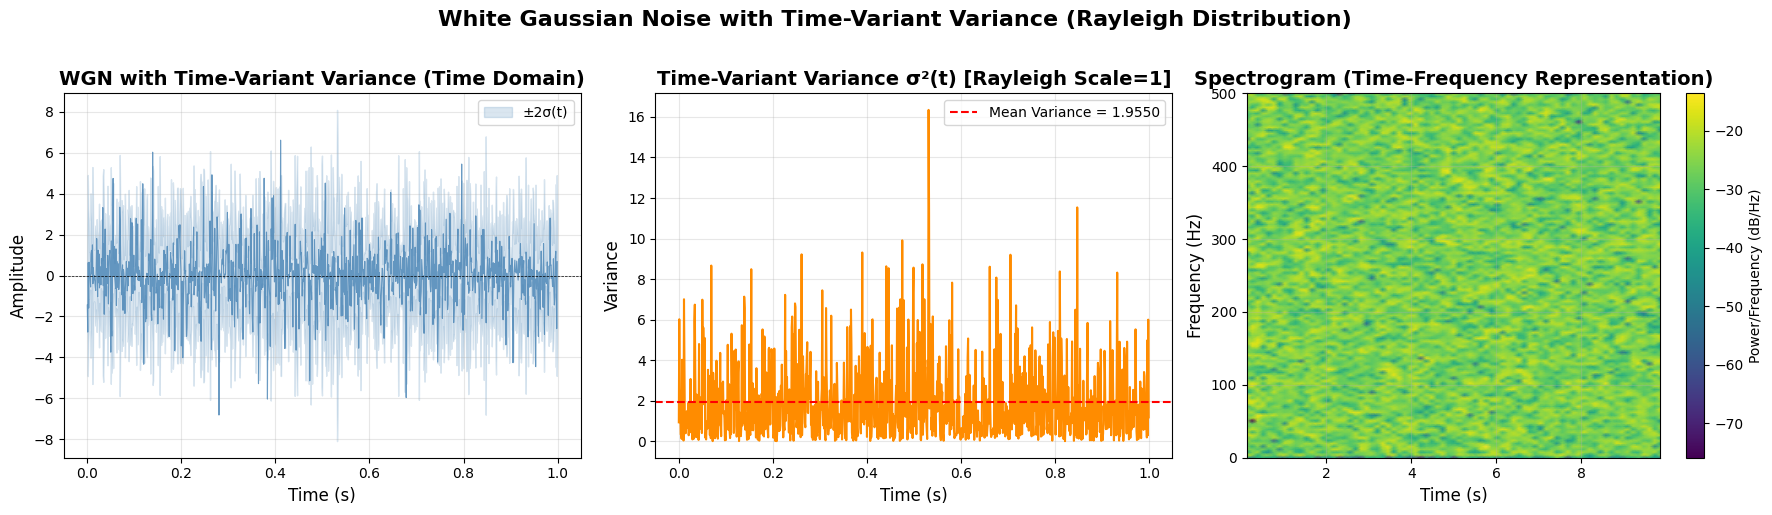

WGN WITH TIME-VARIANT VARIANCE STATISTICS
Number of samples:              10000
Sampling frequency:             1000 Hz
Rayleigh scale parameter:       1
Mean of time-variant std:       1.239216
Mean of time-variant variance:  1.954998
Std of time-variant variance:   1.948712
Min variance:                   0.000023
Max variance:                   16.344891
Signal mean:                    0.010144
Signal variance (overall):      1.911730

RAYLEIGH DISTRIBUTION THEORETICAL VALUES (scale=1):
Mean of Rayleigh:               1.253314
Variance of Rayleigh:           0.429204
Mean of Variance (σ²):          2.000000


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# Parameters
# ============================================================
np.random.seed(42)          # For reproducibility
N = 10000                   # Number of samples
fs = 1000                   # Sampling frequency (Hz)
rayleigh_scale = 1          # Scale parameter of Rayleigh distribution

# ============================================================
# Generate Time-Variant Variance (Rayleigh Distribution)
# ============================================================
# Rayleigh distribution for variance (sigma^2 varies over time)
time_variant_std = np.random.rayleigh(scale=rayleigh_scale, size=N)
time_variant_var = time_variant_std ** 2  # Variance = std^2

# ============================================================
# Generate WGN with Time-Variant Variance
# ============================================================
# Each sample has its own variance drawn from Rayleigh distribution
base_noise = np.random.normal(loc=0, scale=1, size=N)
wgn_tv = base_noise * time_variant_std  # Scale by time-variant std

t = np.arange(N) / fs       # Time vector (seconds)

# ============================================================
# Compute Spectrogram
# ============================================================
# Parameters for spectrogram
nperseg = 256               # Window size
noverlap = 128              # Overlap between windows

freqs, times_spec, Sxx = spectrogram(
    wgn_tv,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    scaling='density'
)

# ============================================================
# Plotting - All Three in One Row
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Time Domain Signal ---
axes[0].plot(t[:1000], wgn_tv[:1000], linewidth=0.8, color='steelblue', alpha=0.8)
axes[0].set_title('WGN with Time-Variant Variance (Time Domain)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Amplitude', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Add envelope showing variance variation
envelope = 2 * time_variant_std[:1000]
axes[0].fill_between(t[:1000], -envelope, envelope,
                     color='steelblue', alpha=0.2, label='±2σ(t)')
axes[0].legend(loc='upper right', fontsize=10)

# --- Plot 2: Time-Variant Variance ---
axes[1].plot(t[:1000], time_variant_var[:1000], linewidth=1.5, color='darkorange')
axes[1].set_title('Time-Variant Variance σ²(t) [Rayleigh Scale=1]',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('Variance', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=np.mean(time_variant_var), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean Variance = {np.mean(time_variant_var):.4f}')
axes[1].legend(loc='upper right', fontsize=10)

# --- Plot 3: Spectrogram ---
# Convert to dB for better visualization
Sxx_db = 10 * np.log10(Sxx + 1e-10)

im = axes[2].pcolormesh(times_spec, freqs, Sxx_db,
                        shading='gouraud', cmap='viridis')
axes[2].set_title('Spectrogram (Time-Frequency Representation)',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Frequency (Hz)', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(im, ax=axes[2], label='Power/Frequency (dB/Hz)')
cbar.ax.tick_params(labelsize=10)

# ============================================================
# Final Formatting
# ============================================================
plt.suptitle('White Gaussian Noise with Time-Variant Variance (Rayleigh Distribution)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Print Key Statistics
# ============================================================
print("=" * 70)
print("WGN WITH TIME-VARIANT VARIANCE STATISTICS")
print("=" * 70)
print(f"Number of samples:              {N}")
print(f"Sampling frequency:             {fs} Hz")
print(f"Rayleigh scale parameter:       {rayleigh_scale}")
print(f"Mean of time-variant std:       {np.mean(time_variant_std):.6f}")
print(f"Mean of time-variant variance:  {np.mean(time_variant_var):.6f}")
print(f"Std of time-variant variance:   {np.std(time_variant_var):.6f}")
print(f"Min variance:                   {np.min(time_variant_var):.6f}")
print(f"Max variance:                   {np.max(time_variant_var):.6f}")
print(f"Signal mean:                    {np.mean(wgn_tv):.6f}")
print(f"Signal variance (overall):      {np.var(wgn_tv):.6f}")
print("=" * 70)

# ============================================================
# Rayleigh Distribution Theoretical Values
# ============================================================
print("\nRAYLEIGH DISTRIBUTION THEORETICAL VALUES (scale=1):")
print(f"Mean of Rayleigh:               {rayleigh_scale * np.sqrt(np.pi/2):.6f}")
print(f"Variance of Rayleigh:           {(4-np.pi)/2 * rayleigh_scale**2:.6f}")
print(f"Mean of Variance (σ²):          {rayleigh_scale**2 * 2:.6f}")
print("=" * 70)

PART 1: STANDARD WHITE GAUSSIAN NOISE (STATIONARY)
--------------------------------------------------------------------------------
Theoretical one-sided PSD, σ²=1: 0.001953 power/Hz
Estimated mean PSD:              0.001954 power/Hz
Relative error:                  0.06%


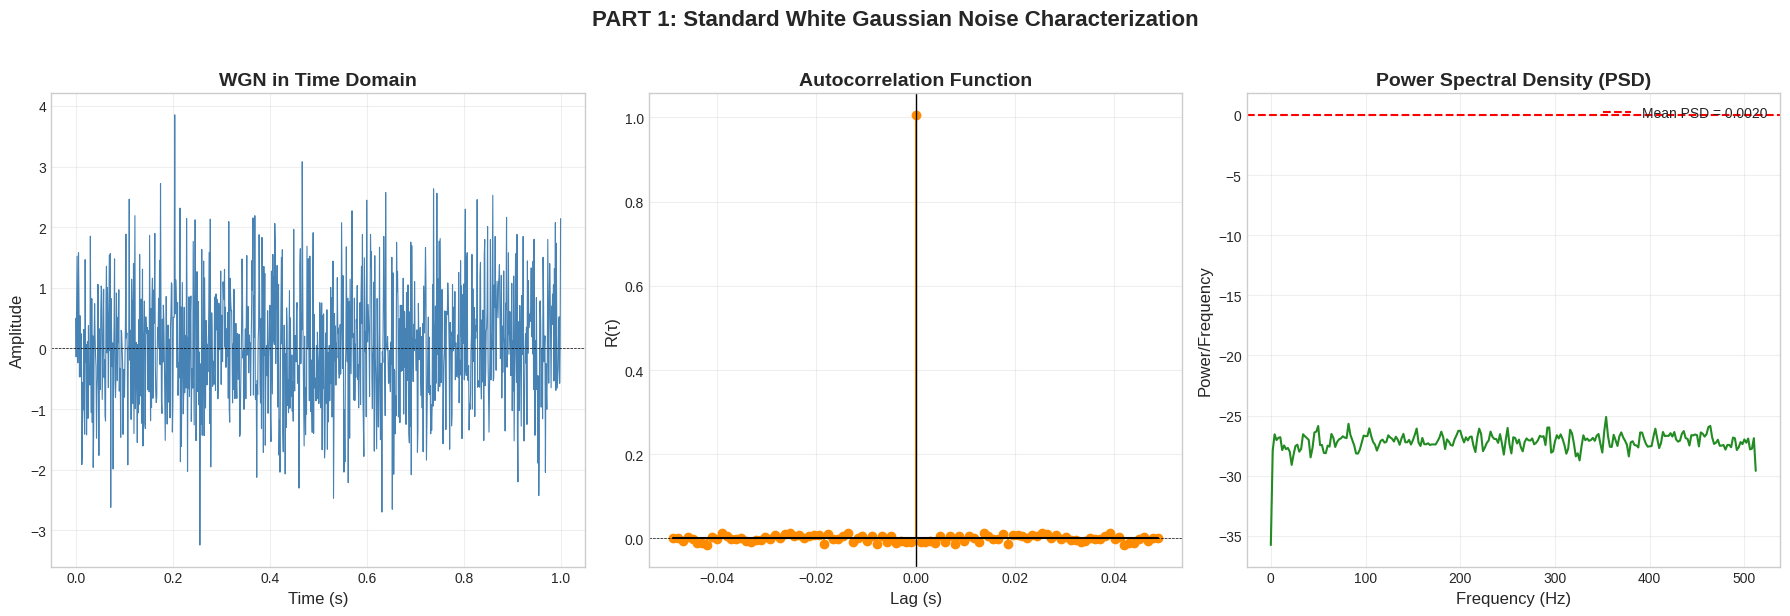


PART 1 STATISTICS
--------------------------------------------------------------------------------
Number of samples:          16384
Sampling frequency:         1024 Hz
Standard deviation (σ):     1
Mean of WGN:                0.001467
Variance of WGN:            1.006164
Autocorr at lag 0:          1.006167
Mean PSD value:             0.001954

PART 2: WGN WITH TIME-VARIANT VARIANCE (NON-STATIONARY)


/tmp/ipykernel_210/4021218506.py:203: UserWarning: Glyph 7523 (\N{LATIN SUBSCRIPT SMALL LETTER R}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7523 (\N{LATIN SUBSCRIPT SMALL LETTER R}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


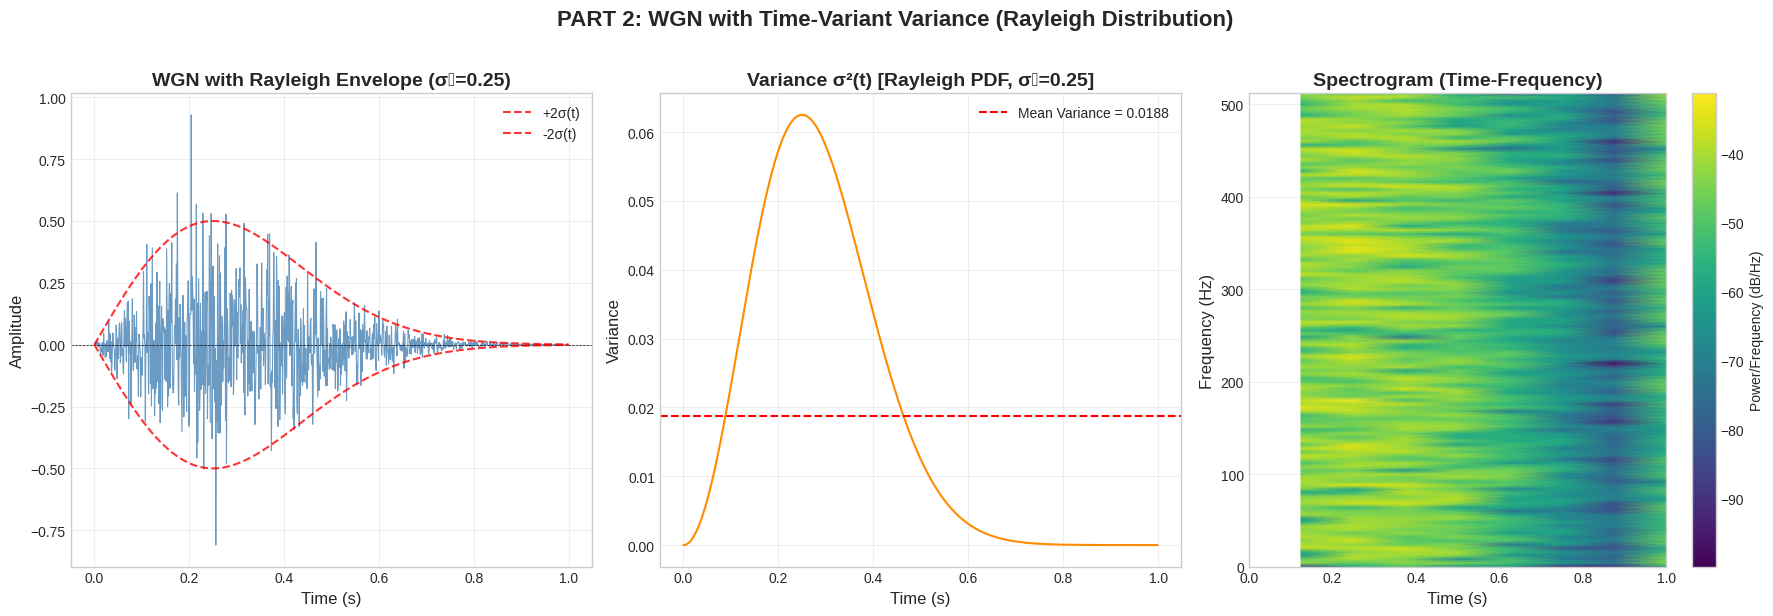


--------------------------------------------------------------------------------
PART 2 STATISTICS
--------------------------------------------------------------------------------
Number of samples:              16384
Sampling frequency:             1024 Hz
Rayleigh scale parameter:       0.25
Mean of time-variant std:       0.103010
Mean of time-variant variance:  0.018820
Std of time-variant variance:   0.022218
Min variance:                   0.000000
Max variance:                   0.062500
Signal mean:                    -0.000074
Signal variance (overall):      0.019096
--------------------------------------------------------------------------------

DETERMINISTIC RAYLEIGH PDF PROPERTIES (scale=0.25):
Peak location (mode):           0.2500 s
Peak value (normalized):        0.2500
Effective period (T_max):       1.0000 s
Mean of envelope σ(t):          0.1030
Mean of variance σ²(t):         0.0188

COMPARISON SUMMARY: PART 1 vs PART 2
---------------------------------------------

In [8]:
# ============================================================================
# WHITE GAUSSIAN NOISE (WGN) COMPLETE SIMULATION NOTEBOOK
# ============================================================================
# This notebook demonstrates:
#   Part 1: Standard White Gaussian Noise (stationary)
#   Part 2: WGN with Time-Variant Variance (Rayleigh-distributed, non-stationary)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch, spectrogram

# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# ============================================================================
# PART 1: STANDARD WHITE GAUSSIAN NOISE (STATIONARY)
# ============================================================================
print("=" * 80)
print("PART 1: STANDARD WHITE GAUSSIAN NOISE (STATIONARY)")
print("-" * 80)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
np.random.seed(42)
N1 = 16384
fs1 = 1024
sigma1 = 1

# ------------------------------------------------------------
# Generate Standard WGN
# ------------------------------------------------------------
wgn_standard = np.random.normal(loc=0, scale=sigma1, size=N1)
t1 = np.arange(N1) / fs1


# ------------------------------------------------------------
# Compute Autocorrelation Function
# ------------------------------------------------------------
autocorr = correlate(wgn_standard, wgn_standard, mode='full') / N1
lags = np.arange(-N1+1, N1) / fs1
mid = len(autocorr) // 2
lag_range = 50
autocorr_plot = autocorr[mid-lag_range:mid+lag_range+1]
lags_plot = lags[mid-lag_range:mid+lag_range+1]

# ------------------------------------------------------------
# Compute Power Spectral Density (PSD)
# ------------------------------------------------------------
freqs, psd = welch(wgn_standard, fs=fs1, nperseg=512)
# After computing PSD with Welch's method:
theoretical_psd_one_sided = 2 * sigma1**2 / fs1
estimated_psd = np.mean(psd)

print(f"Theoretical one-sided PSD, σ²=1: {theoretical_psd_one_sided:.6f} power/Hz")
print(f"Estimated mean PSD:              {estimated_psd:.6f} power/Hz")
print(f"Relative error:                  {abs(estimated_psd - theoretical_psd_one_sided)/theoretical_psd_one_sided * 100:.2f}%")

# ------------------------------------------------------------
# Plot Part 1: Three Characterizations in One Row
# ------------------------------------------------------------
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1.1: Time Domain
axes1[0].plot(t1[:1024], wgn_standard[:1024], linewidth=0.8, color='steelblue')
axes1[0].set_title('WGN in Time Domain', fontsize=14, fontweight='bold')
axes1[0].set_xlabel('Time (s)', fontsize=12)
axes1[0].set_ylabel('Amplitude', fontsize=12)
axes1[0].grid(True, alpha=0.3)
axes1[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Plot 1.2: Autocorrelation
axes1[1].stem(lags_plot, autocorr_plot, linefmt='darkorange',
              markerfmt='o', basefmt='k-')
axes1[1].set_title('Autocorrelation Function', fontsize=14, fontweight='bold')
axes1[1].set_xlabel('Lag (s)', fontsize=12)
axes1[1].set_ylabel('R(τ)', fontsize=12)
axes1[1].grid(True, alpha=0.3)
axes1[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes1[1].axvline(x=0, color='k', linestyle='-', linewidth=1)

# Plot 1.3: PSD

psd_db =  10 * np.log10(psd + 1e-10)
axes1[2].plot(freqs, psd_db, linewidth=1.5, color='forestgreen')
axes1[2].set_title('Power Spectral Density (PSD)', fontsize=14, fontweight='bold')
axes1[2].set_xlabel('Frequency (Hz)', fontsize=12)
axes1[2].set_ylabel('Power/Frequency', fontsize=12)
axes1[2].grid(True, alpha=0.3)
axes1[2].axhline(y=np.mean(psd), color='red', linestyle='--',
                 linewidth=1.5, label=f'Mean PSD = {np.mean(psd):.4f}')
axes1[2].legend(loc='upper right', fontsize=10)

plt.suptitle('PART 1: Standard White Gaussian Noise Characterization',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print Statistics Part 1
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("PART 1 STATISTICS")
print("-" * 80)
print(f"Number of samples:          {N1}")
print(f"Sampling frequency:         {fs1} Hz")
print(f"Standard deviation (σ):     {sigma1}")
print(f"Mean of WGN:                {np.mean(wgn_standard):.6f}")
print(f"Variance of WGN:            {np.var(wgn_standard):.6f}")
print(f"Autocorr at lag 0:          {autocorr[mid]:.6f}")
print(f"Mean PSD value:             {np.mean(psd):.6f}")

# ============================================================================
# PART 2: WGN WITH TIME-VARIANT VARIANCE (RAYLEIGH-DISTRIBUTED)
# ============================================================================
print("\n" + "=" * 80)
print("PART 2: WGN WITH TIME-VARIANT VARIANCE (NON-STATIONARY)")

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
np.random.seed(42)
N2 = 16384
fs2 = 1024
rayleigh_scale = .25
# ------------------------------------------------------------
# Generate Deterministic Rayleigh Envelope
# ------------------------------------------------------------
t2 = np.arange(N2) / fs2  # Time vector [0, N2/fs2)
T_max = 4 * rayleigh_scale  # Rayleigh PDF decays after ~4σ

x_rayleigh = (t2 % T_max)  # Periodic mapping for visualization
# Rayleigh distribution for variance (sigma^2 varies over time)
#time_variant_std = np.random.rayleigh(scale=rayleigh_scale, size=N2)
# Rayleigh PDF: f(x; σ) = (x/σ²) · exp(-x²/(2σ²))
time_variant_std = (x_rayleigh / rayleigh_scale**2) * \
                   np.exp(-x_rayleigh**2 / (2 * rayleigh_scale**2))
time_variant_std = time_variant_std / np.max(time_variant_std) * rayleigh_scale

time_variant_var = time_variant_std ** 2

# Generate modulated WGN
base_noise = np.random.normal(loc=0, scale=1, size=N2)
wgn_tv = base_noise * time_variant_std

# ------------------------------------------------------------
# Compute Spectrogram
# ------------------------------------------------------------
nperseg = 256
noverlap = 128
freqs_spec, times_spec, Sxx = spectrogram(
    wgn_tv, fs=fs2, nperseg=nperseg, noverlap=noverlap, scaling='density'
)
Sxx_db = 10 * np.log10(Sxx + 1e-10)

# ------------------------------------------------------------
# Plot Part 2: Three Characterizations in One Row
# ------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))

# Plot 2.1: Time Domain with Envelope
axes2[0].plot(t2[:1024], wgn_tv[:1024], linewidth=0.8, color='steelblue', alpha=0.8)
axes2[0].set_title(f'WGN with Rayleigh Envelope (σᵣ={rayleigh_scale})',
                   fontsize=14, fontweight='bold')
axes2[0].set_xlabel('Time (s)', fontsize=12)
axes2[0].set_ylabel('Amplitude', fontsize=12)
axes2[0].grid(True, alpha=0.3)
axes2[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

envelope = 2 * time_variant_std[:1024]
axes2[0].plot(t2[:1024], envelope, 'r--', linewidth=1.5, alpha=0.8, label='+2σ(t)')
axes2[0].plot(t2[:1024], -envelope, 'r--', linewidth=1.5, alpha=0.8, label='-2σ(t)')
axes2[0].legend(loc='upper right', fontsize=10)

# Plot 2.2: Time-Variant Variance
axes2[1].plot(t2[:1024], time_variant_var[:1024], linewidth=1.5, color='darkorange')
axes2[1].set_title(f'Variance σ²(t) [Rayleigh PDF, σᵣ={rayleigh_scale}]',
                   fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Time (s)', fontsize=12)
axes2[1].set_ylabel('Variance', fontsize=12)
axes2[1].grid(True, alpha=0.3)
axes2[1].axhline(y=np.mean(time_variant_var), color='red', linestyle='--',
                 linewidth=1.5, label=f'Mean Variance = {np.mean(time_variant_var):.4f}')
axes2[1].legend(loc='upper right', fontsize=10)

# Plot 2.3: Spectrogram
im = axes2[2].pcolormesh(times_spec, freqs_spec, Sxx_db,
                         shading='gouraud', cmap='viridis')
axes2[2].set_title('Spectrogram (Time-Frequency)',
                   fontsize=14, fontweight='bold')
axes2[2].set_xlabel('Time (s)', fontsize=12)
axes2[2].set_ylabel('Frequency (Hz)', fontsize=12)
axes2[2].grid(True, alpha=0.3)
axes2[2].set_xlim(0, 1)
cbar = plt.colorbar(im, ax=axes2[2], label='Power/Frequency (dB/Hz)')
cbar.ax.tick_params(labelsize=10)

plt.suptitle('PART 2: WGN with Time-Variant Variance (Rayleigh Distribution)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print Statistics Part 2
# ------------------------------------------------------------
print("\n" + "-" * 80)
print("PART 2 STATISTICS")
print("-" * 80)
print(f"Number of samples:              {N2}")
print(f"Sampling frequency:             {fs2} Hz")
print(f"Rayleigh scale parameter:       {rayleigh_scale}")
print(f"Mean of time-variant std:       {np.mean(time_variant_std):.6f}")
print(f"Mean of time-variant variance:  {np.mean(time_variant_var):.6f}")
print(f"Std of time-variant variance:   {np.std(time_variant_var):.6f}")
print(f"Min variance:                   {np.min(time_variant_var):.6f}")
print(f"Max variance:                   {np.max(time_variant_var):.6f}")
print(f"Signal mean:                    {np.mean(wgn_tv):.6f}")
print(f"Signal variance (overall):      {np.var(wgn_tv):.6f}")
print("-" * 80)

# ------------------------------------------------------------
# Deterministic Rayleigh PDF Properties
# ------------------------------------------------------------
print(f"\nDETERMINISTIC RAYLEIGH PDF PROPERTIES (scale={rayleigh_scale}):")
print(f"Peak location (mode):           {rayleigh_scale:.4f} s")
print(f"Peak value (normalized):        {rayleigh_scale:.4f}")
print(f"Effective period (T_max):       {T_max:.4f} s")
print(f"Mean of envelope σ(t):          {np.mean(time_variant_std):.4f}")
print(f"Mean of variance σ²(t):         {np.mean(time_variant_var):.4f}")


# ============================================================================
# PART 3: COMPARISON SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("COMPARISON SUMMARY: PART 1 vs PART 2")
print("-" * 80)

comparison_data = {
    'Property': ['Stationarity', 'Variance', 'Autocorrelation', 'PSD', 'Applications'],
    'Part 1 (Standard WGN)': ['Stationary', 'Constant (σ²)', 'R(τ) = σ²δ(τ)', 'Flat (constant)',
                               'System analysis, AWGN channels'],
    'Part 2 (Time-Variant)': ['Non-stationary', 'Time-varying (Rayleigh)', 'R(t₁,t₂) varies',
                               'Time-varying power', 'Fading channels, time-varying systems']
}

# Print comparison table
print(f"\n{'Property':<20} | {'Part 1 (Standard WGN)':<30} | {'Part 2 (Time-Variant)':<30}")
print("-" * 85)
for i, prop in enumerate(comparison_data['Property']):
    print(f"{prop:<20} | {comparison_data['Part 1 (Standard WGN)'][i]:<30} | {comparison_data['Part 2 (Time-Variant)'][i]:<30}")

print("\n" + "=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
print("""
1. STANDARD WGN (Part 1):
   - Stationary process with constant statistical properties
   - Ideal model for theoretical analysis
   - Autocorrelation shows delta function at lag 0
   - PSD is flat across all frequencies

2. TIME-VARIANT WGN (Part 2):
   - Non-stationary process with time-varying variance
   - More realistic for practical scenarios (fading, time-varying channels)
   - Variance follows Rayleigh distribution (scale=1)
   - Spectrogram shows time-varying power but broadband characteristic

""")
print("=" * 80)

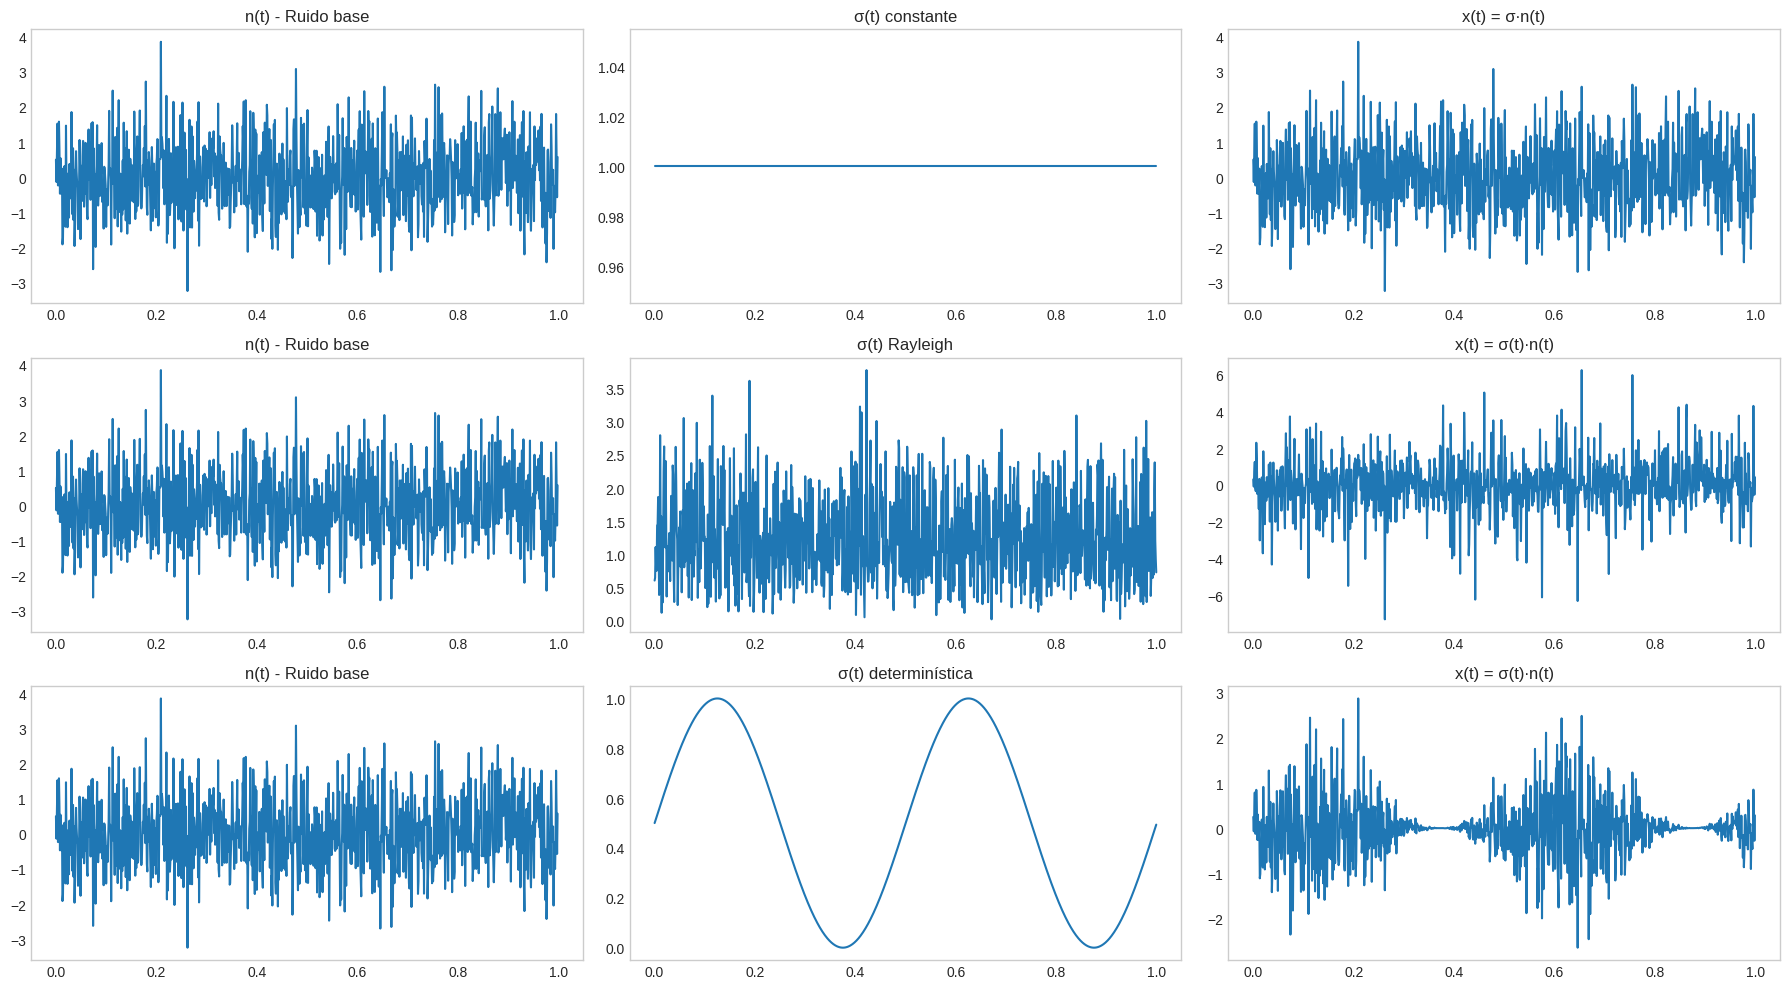

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parámetros generales
N = 5000
fs = 1000
t = np.arange(N) / fs

# Ruido base (N(0,1))
n = np.random.normal(0, 1, N)

# ============================================================
# MODELO 1: WGN ESTÁNDAR (σ constante)
# ============================================================
sigma1 = 1
sigma_t1 = sigma1 * np.ones(N)
x1 = sigma_t1 * n

# ============================================================
# MODELO 2: σ(t) ALEATORIA (Rayleigh)
# ============================================================
sigma_t2 = np.random.rayleigh(scale=1, size=N)
x2 = sigma_t2 * n

# ============================================================
# MODELO 3: σ(t) DETERMINÍSTICA
# ============================================================
sigma_t3 = 0.5 + 0.5 * np.sin(2*np.pi*2*t)  # variación suave
x3 = sigma_t3 * n

# ============================================================
# GRÁFICAS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 10))

# -------- MODELO 1 --------
axes[0,0].plot(t[:1000], n[:1000])
axes[0,0].set_title("n(t) - Ruido base")

axes[0,1].plot(t[:1000], sigma_t1[:1000])
axes[0,1].set_title("σ(t) constante")

axes[0,2].plot(t[:1000], x1[:1000])
axes[0,2].set_title("x(t) = σ·n(t)")

# -------- MODELO 2 --------
axes[1,0].plot(t[:1000], n[:1000])
axes[1,0].set_title("n(t) - Ruido base")

axes[1,1].plot(t[:1000], sigma_t2[:1000])
axes[1,1].set_title("σ(t) Rayleigh")

axes[1,2].plot(t[:1000], x2[:1000])
axes[1,2].set_title("x(t) = σ(t)·n(t)")

# -------- MODELO 3 --------
axes[2,0].plot(t[:1000], n[:1000])
axes[2,0].set_title("n(t) - Ruido base")

axes[2,1].plot(t[:1000], sigma_t3[:1000])
axes[2,1].set_title("σ(t) determinística")

axes[2,2].plot(t[:1000], x3[:1000])
axes[2,2].set_title("x(t) = σ(t)·n(t)")

# Estética
for i in range(3):
    for j in range(3):
        axes[i,j].grid()

plt.tight_layout()
plt.show()

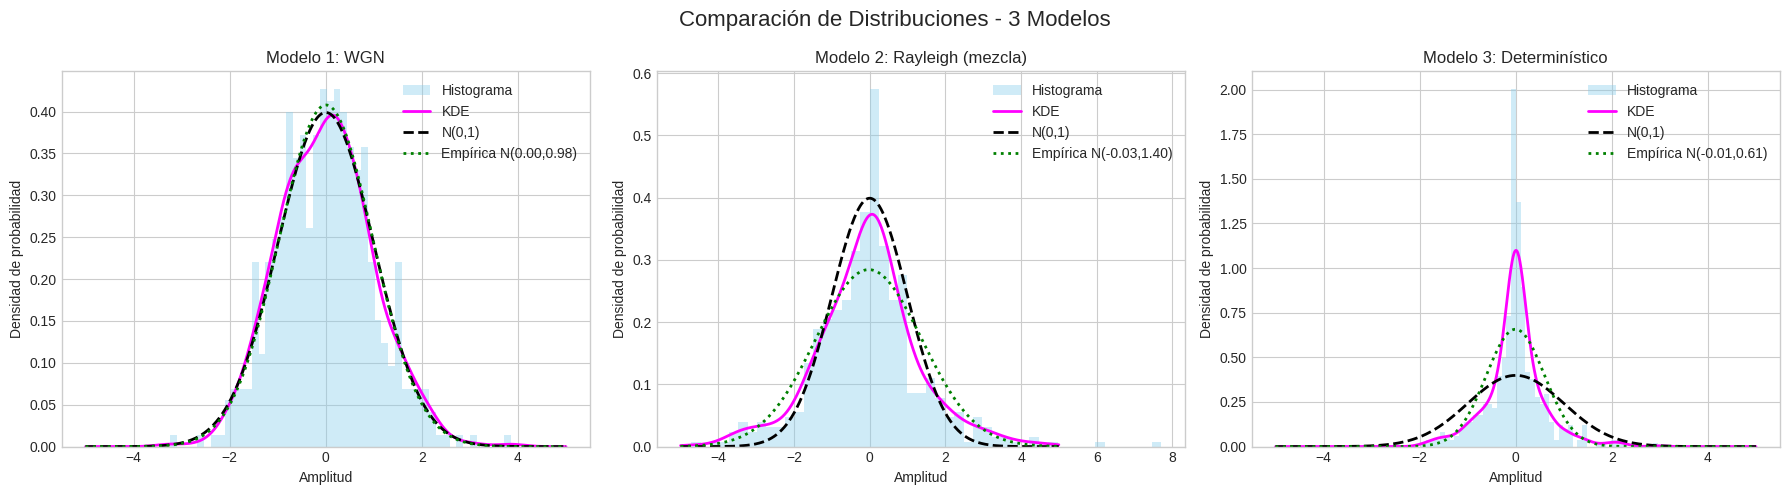

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

np.random.seed(42)

# ============================================================
# Parámetros
# ============================================================
N = 512
t = np.arange(N)

# Ruido base
n = np.random.normal(0, 1, N)

# ============================================================
# MODELOS
# ============================================================

# Modelo 1: WGN estándar
sigma1 = 1
x1 = sigma1 * n

# Modelo 2: σ(t) aleatoria (Rayleigh)
sigma2 = np.random.rayleigh(scale=1, size=N)
x2 = sigma2 * n

# Modelo 3: σ(t) determinística
sigma3 = 0.5 + 0.5 * np.sin(2*np.pi*0.01*t)
x3 = sigma3 * n

signals = [x1, x2, x3]
titles = ["Modelo 1: WGN",
          "Modelo 2: Rayleigh (mezcla)",
          "Modelo 3: Determinístico"]

# ============================================================
# GRÁFICAS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_range = np.linspace(-5, 5, 1000)

for i, (x, ax) in enumerate(zip(signals, axes)):

    # Histograma
    ax.hist(x, bins=50, density=True, alpha=0.4, color='skyblue', label='Histograma')

    # KDE
    kde = gaussian_kde(x)
    ax.plot(x_range, kde(x_range), color='magenta', linewidth=2, label='KDE')

    # Gaussiana teórica N(0,1)
    ax.plot(x_range, norm.pdf(x_range, 0, 1), 'k--', linewidth=2, label='N(0,1)')

    # Gaussiana empírica
    mu = np.mean(x)
    sigma = np.std(x)
    ax.plot(x_range, norm.pdf(x_range, mu, sigma),
            'g:', linewidth=2, label=f'Empírica N({mu:.2f},{sigma:.2f})')

    # Estética
    ax.set_title(titles[i])
    ax.set_xlabel("Amplitud")
    ax.set_ylabel("Densidad de probabilidad")
    ax.grid(True)
    ax.legend()

plt.suptitle("Comparación de Distribuciones - 3 Modelos", fontsize=16)
plt.tight_layout()
plt.show()

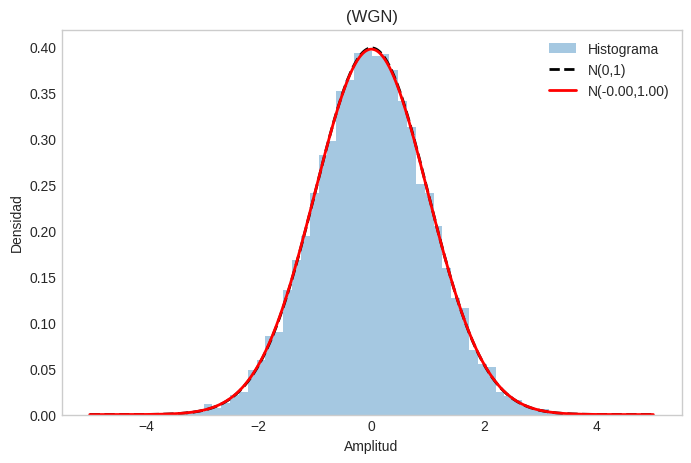

Número de gaussianas usadas: 1


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Datos WGN
N = 10000
x = np.random.normal(0, 1, N)

# Parámetros empíricos
mu = np.mean(x)
sigma = np.std(x)

# Rango
x_range = np.linspace(-5, 5, 1000)

# Gráfica
plt.figure(figsize=(8,5))

# Histograma
plt.hist(x, bins=50, density=True, alpha=0.4, label="Histograma")

# Gaussiana teórica
plt.plot(x_range, norm.pdf(x_range, 0, 1), 'k--', linewidth=2, label="N(0,1)")

# Gaussiana empírica
plt.plot(x_range, norm.pdf(x_range, mu, sigma),
         'r', linewidth=2, label=f"N({mu:.2f},{sigma:.2f})")

plt.title("(WGN)")
plt.xlabel("Amplitud")
plt.ylabel("Densidad")
plt.legend()
plt.grid()
plt.show()

# Resultado
print("Número de gaussianas usadas:", 1)

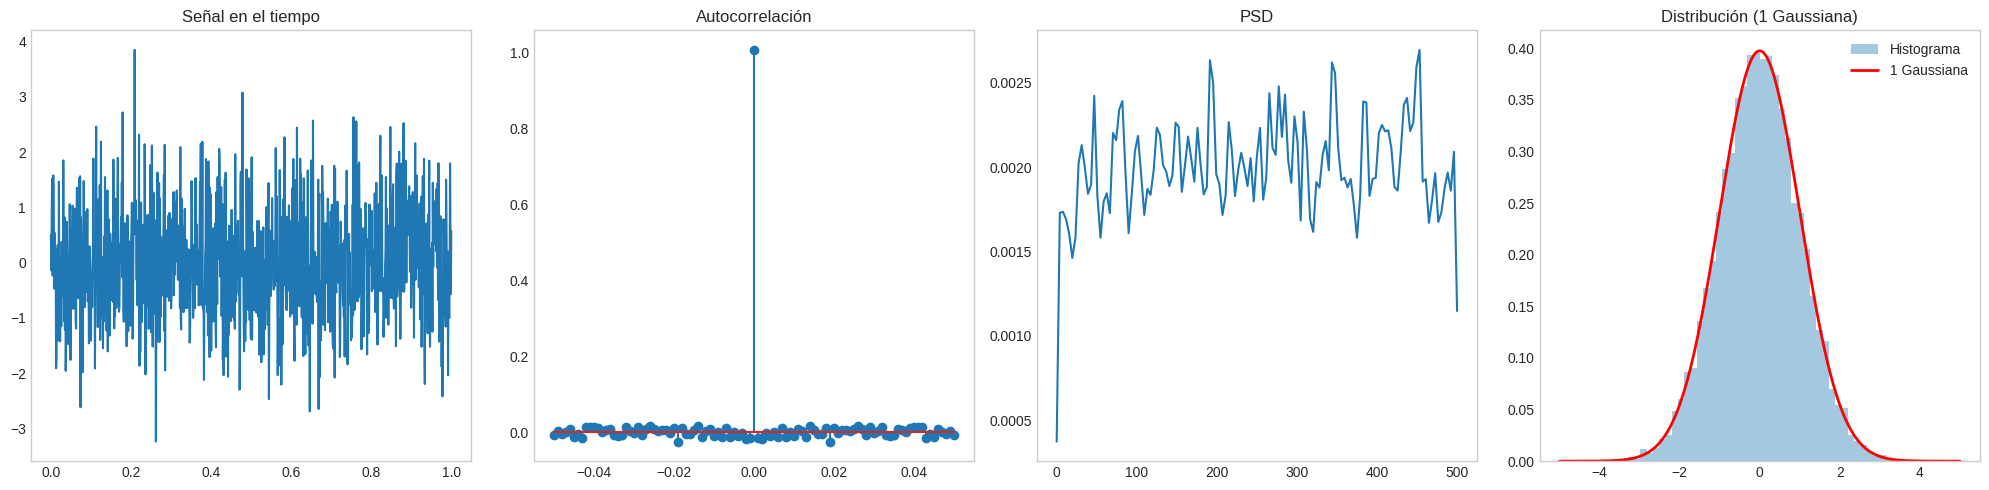

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch
from scipy.stats import norm

np.random.seed(42)

# Parámetros
N = 10000
fs = 1000
t = np.arange(N) / fs

# WGN
x = np.random.normal(0, 1, N)

# =========================
# Autocorrelación
# =========================
autocorr = correlate(x, x, mode='full') / N
lags = np.arange(-N+1, N) / fs

mid = len(autocorr)//2
autocorr_plot = autocorr[mid-50:mid+51]
lags_plot = lags[mid-50:mid+51]

# =========================
# PSD
# =========================
f, psd = welch(x, fs)

# =========================
# Gaussiana única
# =========================
mu = np.mean(x)
sigma = np.std(x)
x_range = np.linspace(-5, 5, 1000)

# =========================
# GRÁFICAS
# =========================
fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Tiempo
axes[0].plot(t[:1000], x[:1000])
axes[0].set_title("Señal en el tiempo")
axes[0].grid()

# Autocorrelación
axes[1].stem(lags_plot, autocorr_plot)
axes[1].set_title("Autocorrelación")
axes[1].grid()

# PSD
axes[2].plot(f, psd)
axes[2].set_title("PSD")
axes[2].grid()

# Distribución (UNA gaussiana)
axes[3].hist(x, bins=50, density=True, alpha=0.4, label="Histograma")
axes[3].plot(x_range, norm.pdf(x_range, mu, sigma),
             'r', linewidth=2, label="1 Gaussiana")
axes[3].set_title("Distribución (1 Gaussiana)")
axes[3].legend()
axes[3].grid()

plt.tight_layout()
plt.show()

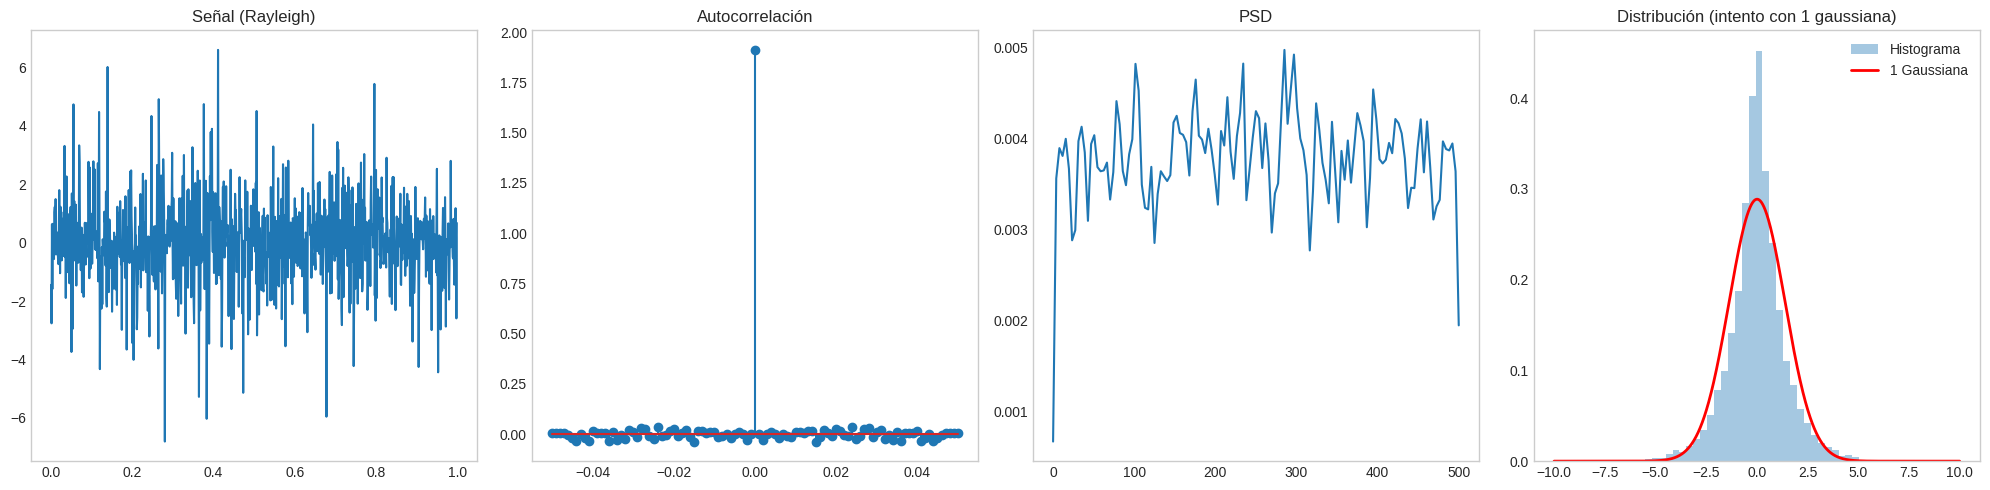

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch
from scipy.stats import norm

np.random.seed(42)

# Parámetros
N = 10000
fs = 1000
t = np.arange(N) / fs

# =========================
# Modelo Rayleigh
# =========================
sigma_t = np.random.rayleigh(scale=1, size=N)
n = np.random.normal(0, 1, N)
x = sigma_t * n

# =========================
# Autocorrelación
# =========================
autocorr = correlate(x, x, mode='full') / N
lags = np.arange(-N+1, N) / fs

mid = len(autocorr)//2
autocorr_plot = autocorr[mid-50:mid+51]
lags_plot = lags[mid-50:mid+51]

# =========================
# PSD
# =========================
f, psd = welch(x, fs)

# =========================
# Ajuste con UNA gaussiana
# =========================
mu = np.mean(x)
sigma = np.std(x)
x_range = np.linspace(-10, 10, 1000)

# =========================
# GRÁFICAS
# =========================
fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Tiempo
axes[0].plot(t[:1000], x[:1000])
axes[0].set_title("Señal (Rayleigh)")
axes[0].grid()

# Autocorrelación
axes[1].stem(lags_plot, autocorr_plot)
axes[1].set_title("Autocorrelación")
axes[1].grid()

# PSD
axes[2].plot(f, psd)
axes[2].set_title("PSD")
axes[2].grid()

# Distribución
axes[3].hist(x, bins=50, density=True, alpha=0.4, label="Histograma")

# Gaussiana única (ajuste)
axes[3].plot(x_range, norm.pdf(x_range, mu, sigma),
             'r', linewidth=2, label="1 Gaussiana")

axes[3].set_title("Distribución (intento con 1 gaussiana)")
axes[3].legend()
axes[3].grid()

plt.tight_layout()
plt.show()

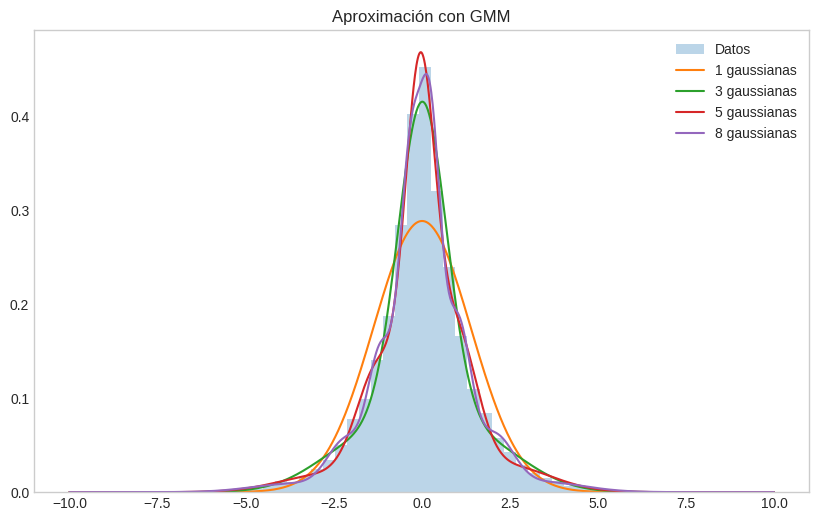

In [19]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Datos (tu señal Rayleigh)
X = x.reshape(-1, 1)

# Probar diferentes K
Ks = [1, 3, 5, 8]

plt.figure(figsize=(10,6))

# Histograma
plt.hist(x, bins=50, density=True, alpha=0.3, label="Datos")

x_range = np.linspace(-10, 10, 1000).reshape(-1,1)

for K in Ks:
    gmm = GaussianMixture(n_components=K, random_state=0)
    gmm.fit(X)

    logprob = gmm.score_samples(x_range)
    pdf = np.exp(logprob)

    plt.plot(x_range, pdf, label=f"{K} gaussianas")

plt.legend()
plt.title("Aproximación con GMM")
plt.grid()
plt.show()

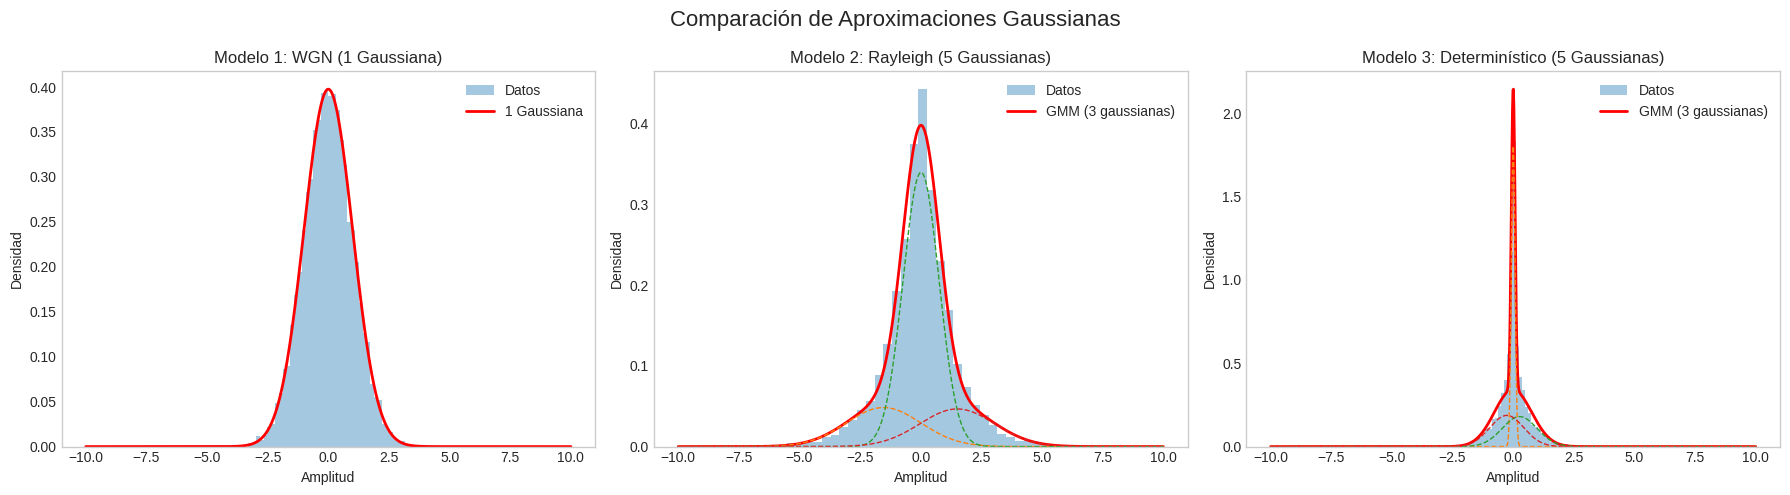

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# ============================================================
# Parámetros
# ============================================================
N = 10000
t = np.arange(N)

# Ruido base
n = np.random.normal(0, 1, N)

# ============================================================
# MODELOS
# ============================================================

# Modelo 1: WGN
x1 = n

# Modelo 2: Rayleigh
sigma2 = np.random.rayleigh(scale=1, size=N)
x2 = sigma2 * n

# Modelo 3: Determinístico
sigma3 = 0.5 + 0.5 * np.sin(2*np.pi*0.01*t)
x3 = sigma3 * n

signals = [x1, x2, x3]
titles = ["Modelo 1: WGN (1 Gaussiana)",
          "Modelo 2: Rayleigh (5 Gaussianas)",
          "Modelo 3: Determinístico (5 Gaussianas)"]

# ============================================================
# Rango para PDF
# ============================================================
x_range = np.linspace(-10, 10, 1000).reshape(-1,1)

# ============================================================
# GRÁFICAS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, (x, ax) in enumerate(zip(signals, axes)):

    # Histograma
    ax.hist(x, bins=50, density=True, alpha=0.4, label="Datos")

    # ===== MODELO 1: 1 GAUSSIANA =====
    if i == 0:
        mu = np.mean(x)
        sigma = np.std(x)
        pdf = norm.pdf(x_range, mu, sigma)
        ax.plot(x_range, pdf, 'r', linewidth=2, label="1 Gaussiana")

    # ===== MODELO 2 y 3: GMM =====
    else:
        X = x.reshape(-1,1)
        gmm = GaussianMixture(n_components=3, random_state=0)
        gmm.fit(X)

        logprob = gmm.score_samples(x_range)
        pdf = np.exp(logprob)
        ax.plot(x_range, pdf, 'r', linewidth=2, label="GMM (3 gaussianas)")

        # (Opcional) Mostrar cada gaussiana individual
        for k in range(3):
            weight = gmm.weights_[k]
            mean = gmm.means_[k][0]
            std = np.sqrt(gmm.covariances_[k][0][0])
            component = weight * norm.pdf(x_range, mean, std)
            ax.plot(x_range, component, '--', linewidth=1)

    # Estética
    ax.set_title(titles[i])
    ax.set_xlabel("Amplitud")
    ax.set_ylabel("Densidad")
    ax.grid()
    ax.legend()

plt.suptitle("Comparación de Aproximaciones Gaussianas", fontsize=16)
plt.tight_layout()
plt.show()